<a href="https://colab.research.google.com/github/enzoura07/Teoria-do-aprendizado-estatisco/blob/main/reg_log_ridge_e_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Loading required package: Matrix

Loaded glmnet 5.0



Dados filtrados com sucesso! Total de observacoes: 81443 

===== ODDS RATIOS: MODELO ORIGINAL (glm) =====
                                               OR 2.5 % 97.5 %
(Intercept)                                 0.350 0.317  0.388
IDADE                                       1.021 1.020  1.022
ESCOLARIDADE1 a 3 anos                      0.773 0.718  0.832
ESCOLARIDADE4 a 7 anos                      0.649 0.607  0.695
ESCOLARIDADE8 a 11 anos                     0.578 0.540  0.618
ESCOLARIDADE12 anos ou mais                 0.517 0.477  0.560
LOCAL_MORTEOutros estabelecimentos de saúde 0.871 0.832  0.912
LOCAL_MORTEDomicílio                        0.766 0.731  0.802
LOCAL_MORTEOutros                           0.751 0.672  0.840
LOCAL_MORTEVia pública                      0.212 0.173  0.259

===== COMPARACAO LOGISTICA x RIDGE x LASSO =====
              Modelo Acuracia_teste Deviance_teste
1    Logistica (glm)         0.6032          1.323
2 Ridge (lambda.min)         0.6038          1.32

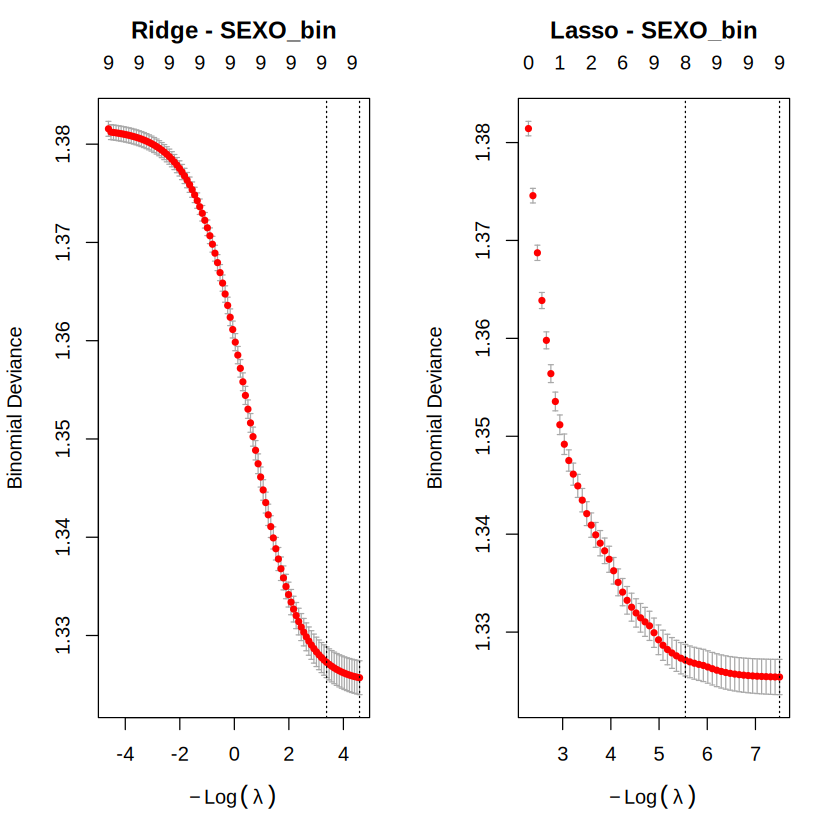

In [1]:

# Regressao Logistica - SEXO_bin ~ IDADE + ESCOLARIDADE + LOCAL_MORTE



# 0) Instalacao e carregamento seguro dos pacotes

if (!require("glmnet", quietly = TRUE)) install.packages("glmnet", repos = "https://cloud.r-project.org/")
if (!require("readxl", quietly = TRUE)) install.packages("readxl", repos = "https://cloud.r-project.org/")

library(glmnet)
library(readxl)


# 1) Leitura, limpeza e preparo dos dados (suporta CSV ou Excel)

if (file.exists("DatasetSIM_tratado.csv")) {
  dados <- read.csv2("DatasetSIM_tratado.csv", encoding = "UTF-8", na.strings = c("", "NA", "nan", "NaN"), stringsAsFactors = FALSE)
} else if (file.exists("datasetDEF_translated.xlsx")) {
  dados <- as.data.frame(read_excel("datasetDEF_translated.xlsx"))
} else if (file.exists("/content/datasetDEF_translated.xlsx")) {
  dados <- as.data.frame(read_excel("/content/datasetDEF_translated.xlsx"))
} else if (file.exists("/content/DatasetSIM_tratado.csv")) {
  dados <- read.csv2("/content/DatasetSIM_tratado.csv", encoding = "UTF-8", na.strings = c("", "NA", "nan", "NaN"), stringsAsFactors = FALSE)
} else {
  stop("ERRO: Ficheiro de dados nao encontrado! Verifique se o ficheiro .csv ou .xlsx esta na pasta de trabalho.")
}

dados$IDADE <- as.numeric(dados$IDADE)

dados_limpos <- subset(
  dados,
  SEXO %in% c("Masculino", "Feminino") &
  !is.na(IDADE) &
  ESCOLARIDADE %in% c(
    "Nenhuma", "1 a 3 anos", "4 a 7 anos", "8 a 11 anos", "12 anos ou mais"
  ) &
  LOCAL_MORTE %in% c(
    "Hospital", "Outros estabelecimentos de saúde", "Domicílio", "Outros", "Via pública"
  )
)

dados_limpos$SEXO_bin <- ifelse(dados_limpos$SEXO == "Feminino", 1, 0)

dados_limpos$ESCOLARIDADE <- factor(
  dados_limpos$ESCOLARIDADE,
  levels = c("Nenhuma", "1 a 3 anos", "4 a 7 anos", "8 a 11 anos", "12 anos ou mais")
)
dados_limpos$ESCOLARIDADE <- relevel(dados_limpos$ESCOLARIDADE, ref = "Nenhuma")

dados_limpos$LOCAL_MORTE <- factor(
  dados_limpos$LOCAL_MORTE,
  levels = c("Hospital", "Outros estabelecimentos de saúde", "Domicílio", "Outros", "Via pública")
)
dados_limpos$LOCAL_MORTE <- relevel(dados_limpos$LOCAL_MORTE, ref = "Hospital")

# Limpa niveis de fatores sem observacoes apos o subset
dados_limpos <- droplevels(dados_limpos)

if (nrow(dados_limpos) == 0) {
  stop("ERRO: O conjunto de dados ficou vazio apos os filtros! Verifique os nomes das categorias no dataset.")
}

cat("Dados filtrados com sucesso! Total de observacoes:", nrow(dados_limpos), "\n")


# 2) Divisao treino/teste (70/30)

set.seed(42)
n <- nrow(dados_limpos)
indice_treino <- sample(seq_len(n), size = round(0.7 * n))
treino <- dados_limpos[indice_treino, ]
teste  <- dados_limpos[-indice_treino, ]


# 3) Modelo original (glm)

modelo <- glm(
  SEXO_bin ~ IDADE + ESCOLARIDADE + LOCAL_MORTE,
  data = treino,
  family = binomial(link = "logit")
)

cat("\n===== ODDS RATIOS: MODELO ORIGINAL (glm) =====\n")
# Uso de confint.default (Wald) para evitar bloqueios em bases de dados grandes
print(round(exp(cbind(OR = coef(modelo), confint.default(modelo))), 3))

teste$prob_glm <- predict(modelo, newdata = teste, type = "response")
teste$classe_glm <- ifelse(teste$prob_glm >= 0.5, 1, 0)

acc_glm <- mean(teste$classe_glm == teste$SEXO_bin)


# 4) Matrizes para o glmnet

X_treino <- model.matrix(SEXO_bin ~ IDADE + ESCOLARIDADE + LOCAL_MORTE, data = treino)[, -1]
y_treino <- treino$SEXO_bin
X_teste  <- model.matrix(SEXO_bin ~ IDADE + ESCOLARIDADE + LOCAL_MORTE, data = teste)[, -1]
y_teste  <- teste$SEXO_bin


# 5) Ridge (alpha = 0) e Lasso (alpha = 1), family = "binomial"

set.seed(1)
cv_ridge <- cv.glmnet(X_treino, y_treino, family = "binomial", alpha = 0)
set.seed(1)
cv_lasso <- cv.glmnet(X_treino, y_treino, family = "binomial", alpha = 1)

prob_ridge <- as.vector(predict(cv_ridge, X_teste, s = "lambda.min", type = "response"))
prob_lasso <- as.vector(predict(cv_lasso, X_teste, s = "lambda.1se", type = "response"))

acc_ridge <- mean(ifelse(prob_ridge >= 0.5, 1, 0) == y_teste)
acc_lasso <- mean(ifelse(prob_lasso >= 0.5, 1, 0) == y_teste)

# Deviance de teste (log-loss x2) - menor e melhor
devi <- function(prob, obs) {
  p <- pmin(pmax(prob, 1e-6), 1 - 1e-6)
  -2 * mean(obs * log(p) + (1 - obs) * log(1 - p))
}

dev_glm   <- devi(teste$prob_glm, y_teste)
dev_ridge <- devi(prob_ridge, y_teste)
dev_lasso <- devi(prob_lasso, y_teste)


# 6) Tabela comparativa

comparacao <- data.frame(
  Modelo         = c("Logistica (glm)", "Ridge (lambda.min)", "Lasso (lambda.1se)"),
  Acuracia_teste = round(c(acc_glm, acc_ridge, acc_lasso), 4),
  Deviance_teste = round(c(dev_glm, dev_ridge, dev_lasso), 3)
)

cat("\n===== COMPARACAO LOGISTICA x RIDGE x LASSO =====\n")
print(comparacao)


# 7) Coeficientes lado a lado

cat("\n===== COEFICIENTES: RIDGE (lambda.min) =====\n")
print(round(as.matrix(coef(cv_ridge, s = "lambda.min")), 4))

coef_lasso <- as.matrix(coef(cv_lasso, s = "lambda.1se"))
cat("\n===== COEFICIENTES: LASSO (lambda.1se) - todos =====\n")
print(round(coef_lasso, 4))
cat("\n===== LASSO - apenas os que sobreviveram (!= 0) =====\n")
print(round(coef_lasso[as.vector(coef_lasso) != 0, , drop = FALSE], 4))

cat("\nlambda.min (Ridge):", round(cv_ridge$lambda.min, 4), "\n")
cat("lambda.min (Lasso):", round(cv_lasso$lambda.min, 4),
    "| lambda.1se (Lasso):", round(cv_lasso$lambda.1se, 4), "\n")


# 8) Curvas de validacao cruzada

par(mfrow = c(1, 2))
plot(cv_ridge); title("Ridge - SEXO_bin", line = 2.5)
plot(cv_lasso); title("Lasso - SEXO_bin", line = 2.5)